**3.1 Vecinos**

In [ ]:

/// INTERPOLACION VECINO
real mn_interpolacion_vecino(
Array1D<real> &x, /// puntos de interpolación
Array1D<real> &f, /// valores de función en los puntos de interpolación
real x0)  /// punto donde se evalua la función interpolada
{
  for(int i = f.dim() - 2; i >= 0; i = i - 1) {
    if (x[i] < x0) {
        if ((x0 - x[i]) <= mn_abs(x0 - x[i + 1])) {
            return f[i];
        } 
        else {
            return f[i + 1];
        }
    }
  }
  return f[0];
}

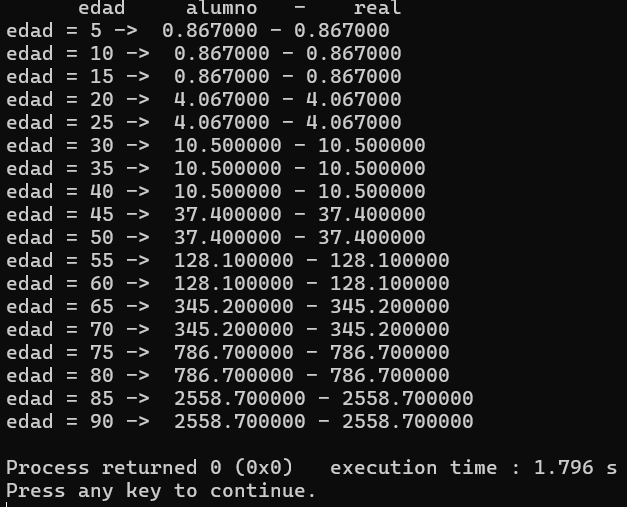

**3.2 Lineal**

In [ ]:
/// INTERPOLACION LINEAL
real mn_interpolacion_lineal(
Array1D<real> &x, /// puntos de interpolación
Array1D<real> &f, /// valores de función en los puntos de interpolación
real x0)  /// punto donde se evalua la función interpolada
{
    for(int i=f.dim()-2; i>=0; i=i-1){
        if( x[i]<x0 ){
        return f[i]+(x0-x[i])*(f[i+1]-f[i])/(x[i+1]-x[i]);
        }
    }
    return f[0]+(x0-x[0])*(f[1]-f[0])/(x[1]-x[0]);
}

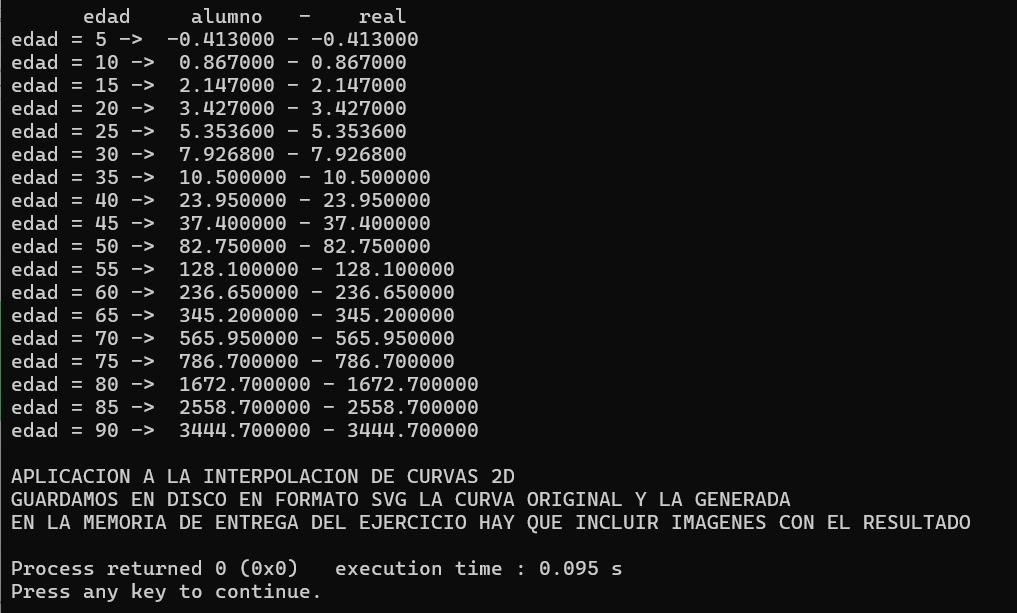

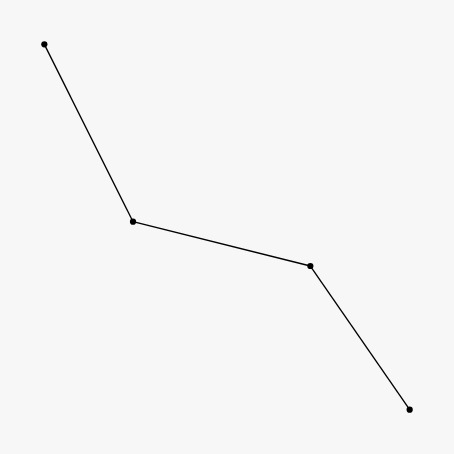

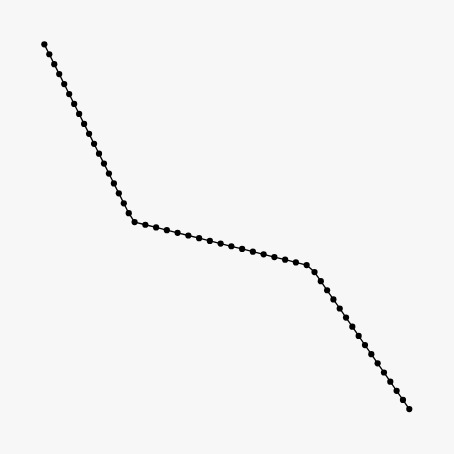

**3.3 Splines de grado 2 C0 (Lagrange)**

In [ ]:
int mn_calculo_splines_2(
 Array1D< real > &x, /// vector con los puntos de interpolación
 Array1D< real > &f, /// vector con los valores de la función
 real &c0,           /// valor de c[0] asignado como parámetro
Array1D< real > &a,       /// vector de salida con los coeficientes a[i] del spline de grado 2
Array1D< real > &b,       /// vector de salida con los coeficientes b[i] del spline de grado 2
Array1D< real > &c)       /// vector de salida con los coeficientes c[i] del spline de grado 2
{
    if(f.dim()!=x.dim() || f.dim()<2 ) return -1;
    for(int k=1;k<x.dim();k++){
        if(x[k]<=x[k-1]) return -1;
    }
    a=Array1D< real >(x.dim()-1);
    b=Array1D< real >(x.dim()-1);
    c=Array1D< real >(x.dim()-1);
    a[0]=f[0];
    b[0]=(f[1]-f[0]-c0*(x[1]-x[0])*(x[1]-x[0]))/(x[1]-x[0]);
    c[0]=c0;

    for(int i=1;i<a.dim();i++){
        a[i]=f[i];
        b[i]=b[i-1]+2*c[i-1]*(x[i]-x[i-1]);
        c[i]=(f[i+1]-a[i]-b[i]*(x[i+1]-x[i]))/((x[i+1]-x[i])*(x[i+1]-x[i]));
    }

    return 0;
}

real mn_evaluar_splines_2(
Array1D< real > &x,
Array1D< real > &a,
Array1D< real > &b,
Array1D< real > &c,
real x0 ){
    for(int i=a.dim()-1;i>=0;i--){
        if(x[i]<x0) return a[i]+(b[i]+c[i]*(x0-x[i]))*(x0-x[i]); ///fórmula de P(x)
    }
    return a[0]+(b[0]+c[0]*(x0-x[0]))*(x0-x[0]);
}

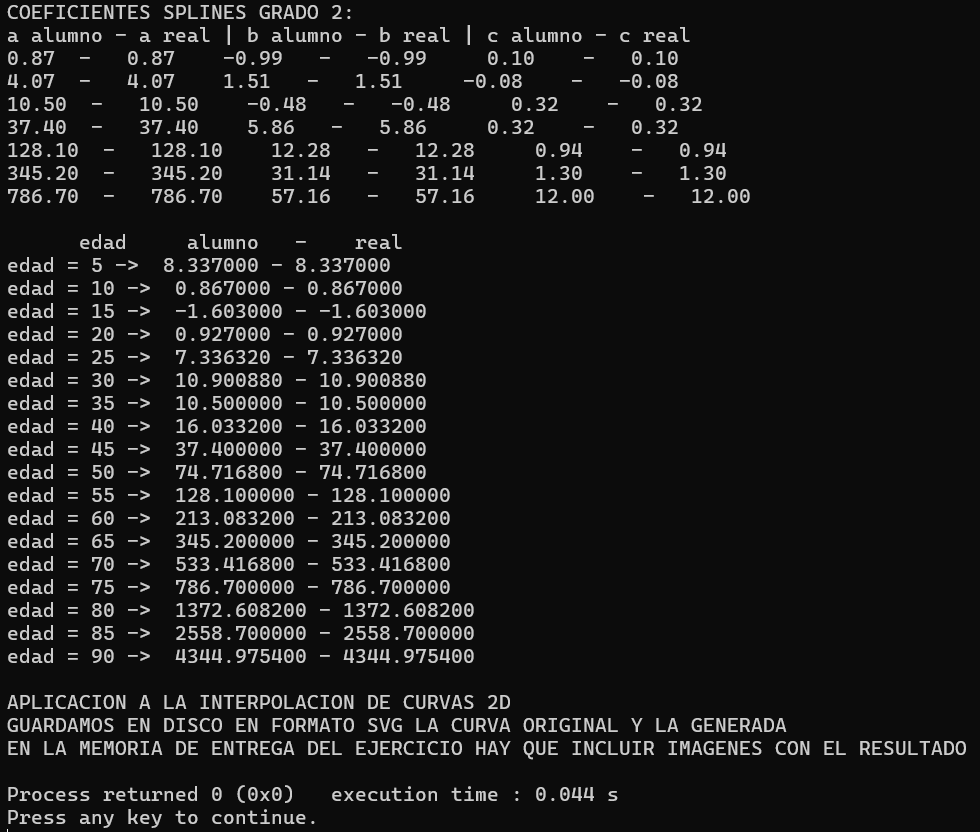

![alt text](curva_original-2.svg)

![alt text](curva-2.svg)

**3.4 Splines de grado 2 Cn-1**

In [ ]:
int mn_calculo_splines_2(
const Array1D< real > &x, /// vector con los puntos de interpolación
const Array1D< real > &f, /// vector con los valores de la función
const real &cLast,        /// último valor del vector c[] asignado como parámetro
Array1D< real > &a,       /// vector de salida con los coeficientes a[i] del spline de grado 2
Array1D< real > &b,       /// vector de salida con los coeficientes b[i] del spline de grado 2
Array1D< real > &c)       /// vector de salida con los coeficientes c[i] del spline de grado 2
{
  if(f.dim()!=x.dim() || f.dim()<2 ) return -1;

  for(int k=1;k<x.dim();k++){
    if(x[k]<=x[k-1]) return -1;
  }

  a=Array1D< real >(x.dim()-1);
  b=Array1D< real >(x.dim()-1);
  c=Array1D< real >(x.dim()-1);

  a[a.dim()-1]=f[a.dim()-1];
  b[a.dim()-1]=(f[a.dim()]-f[a.dim()-1]-cLast*(x[a.dim()]-x[a.dim()-1])*(x[a.dim()]-x[a.dim()-1]))/(x[a.dim()]-x[a.dim()-1]);
  c[a.dim()-1]=cLast;

  for(int i=a.dim()-2;i>=0;i--){
    a[i]=f[i];
    b[i]=2*(f[i+1]-f[i])/(x[i+1]-x[i])-b[i+1];
    c[i]=(b[i+1]*(x[i+1]-x[i])+f[i]-f[i+1])/((x[i+1]-x[i])*(x[i+1]-x[i]));
  }

  return 0;
}

real mn_evaluar_splines_2(
const Array1D< real > &x,
Array1D< real > &a,
Array1D< real > &b,
Array1D< real > &c,
real x0 ){
  for(int i=a.dim()-1;i>=0;i--){
    if(x[i]<x0) return a[i]+b[i]*(x0-x[i])+c[i]*(x0-x[i])*(x0-x[i]);
  }
  return a[0]+b[0]*(x0-x[0])+c[0]*(x0-x[0])*(x0-x[0]);
}

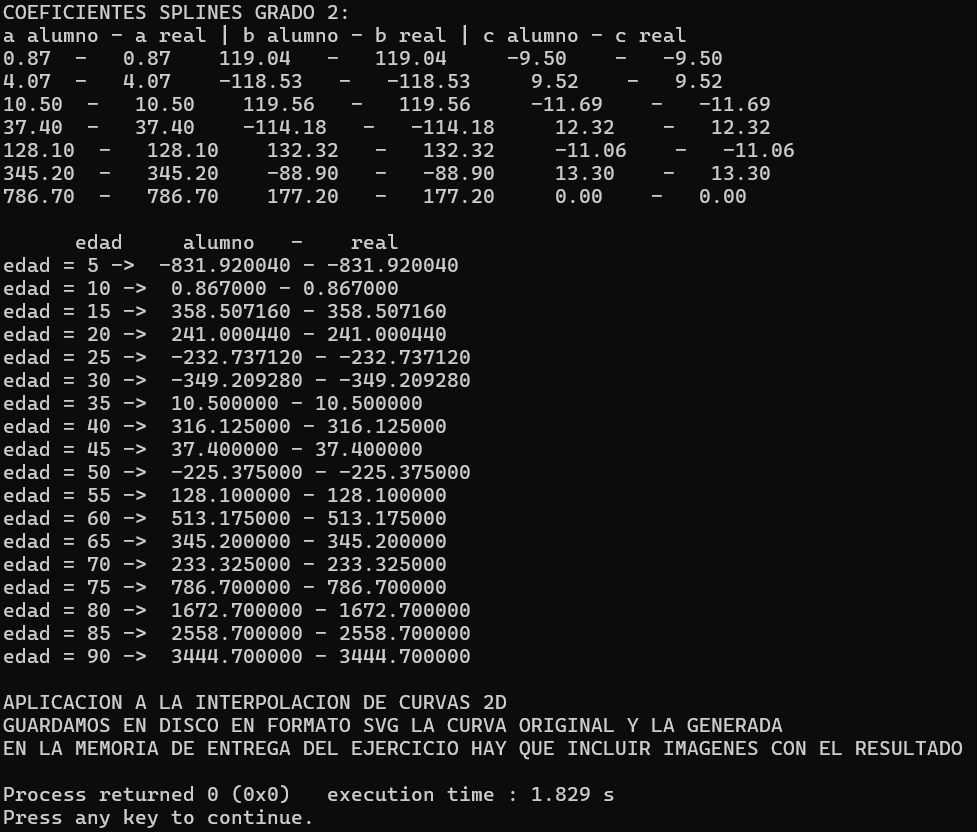

![alt text](curva_original-1.svg)

![alt text](curva-1.svg)

**3.5 Splines de grado 3**

In [ ]:
int mn_calculo_splines_3(
const Array1D< real > &x, /// vector con los puntos de interpolación
const Array1D< real > &f, /// vector con los valores de la función
const real c0,            /// primer valor del vector c[] asignado como parámetro
const real cN,            /// último valor del vector c[] asignado como parámetro
Array1D< real > &a,       /// vector de salida con los coeficientes a[i] del spline de grado 2
Array1D< real > &b,       /// vector de salida con los coeficientes b[i] del spline de grado 2
Array1D< real > &c,       /// vector de salida con los coeficientes c[i] del spline de grado 2
Array1D< real > &d)       /// vector de salida con los coeficientes d[i] del spline de grado 2
{
    ///definimos los arreglos de los splines cúbicos
    Array1D< real > h(x.dim()-1);
    Array1D< real > M(x.dim(),1.);
    Array1D< real > B(x.dim());
    Array1D< real > U(x.dim()-1,0.);
    Array1D< real > L(x.dim()-1,0.);

    for(int k=0; k<h.dim(); k++){ ///calcula las diferencias entre puntos consecutivos de x
        h[k]=x[k+1]-x[k];
    }
    ///asigna los valores de las condiciones de frontera a los extremos
    B[0]=c0;
    B[B.dim()-1]=cN;

    for(int k=1;k<x.dim()-1;k++){
        ///llenamos los arreglos segun las fórmulas
        L[k-1]=h[k-1];
        M[k]=2*(h[k-1]+h[k]);
        U[k]=h[k];
        B[k]=3.*(f[k+1]-f[k])/h[k] - 3.*(f[k]-f[k-1])/h[k-1];
    }
    c=solucion_sistema(L,M,U,B); ///resolvemos el sistema tridiagonal para tener los coeficientes c

    a=Array1D< real >(x.dim()-1);
    b=Array1D< real >(x.dim()-1);
    d=Array1D< real >(x.dim()-1);

    for(int k=0;k<a.dim();k++){ ///calculamos los coeficientes para cada segmento
        a[k]=f[k];
        d[k]=(c[k+1]-c[k])/(3*h[k]);
        b[k]=(f[k+1]-f[k])/h[k]-h[k]*(2*c[k]+c[k+1])/3.;
    }

    return 0;
}

real mn_evaluar_splines_3(
const Array1D< real > &x,
Array1D< real > &a,
Array1D< real > &b,
Array1D< real > &c,
Array1D< real > &d,
real x0 ){
    for(int i=a.dim()-1;i>=0;i--){
        if(x[i]<x0){
        return  ((d[i]*(x0-x[i])+c[i])*(x0-x[i])+b[i])*(x0-x[i])+a[i];
        }
    }
    return ((d[0]*(x0-x[0])+c[0])*(x0-x[0])+b[0])*(x0-x[0])+a[0];
}

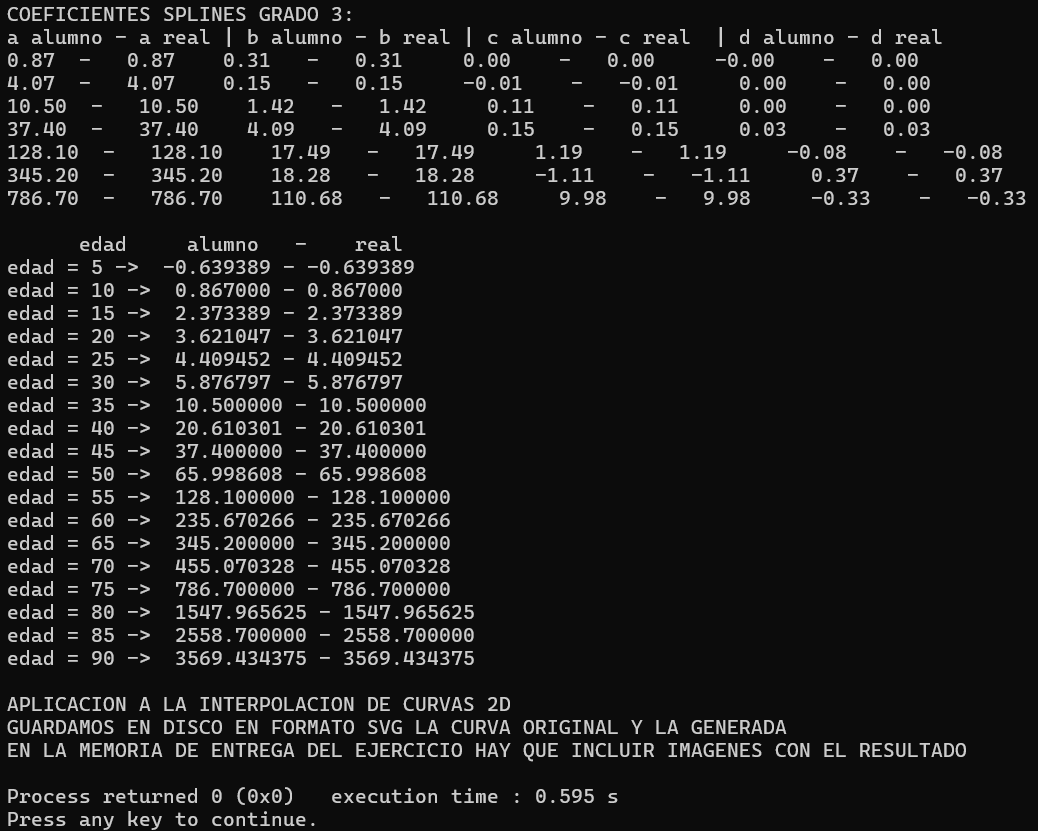

![alt text](curva_original.svg)

![alt text](curva.svg)

Validación: Los resultados aparentemente están bien, pues coinciden con los esperados. El objetivo del 
método es calcular a partir del número de fallecimientos por edad de ciertas edades conocidas 
(puntos interpoladores), el número de fallecimientos de otras (puntos en los que se interpola).  
Asimismo, se conoce el valor de la derivada al principio y al final del primer y último intervalo, 
respectivamente. Para ello, en la primera función que se implementa, se imponen las siguientes 
condiciones: le derivada debe coincidir a la izquierda y a la derecha en cada punto, que el 
polinomio interpolador encerrado por el intervalo comprendido entre los puntos xi y xi+1 debe
pasar por ellos, así como su segunda derivada. Sabiendo esto y montando el sistema de 
ecuaciones que cumpla con ello se obtienen los valores de los coeficientes a, b, c y d. 
Una vez obtenidos los polinomios interpoladores, se evalúa en qué intervalo de edades se 
encuentra la edad que se quiere interpolar y se obtiene el valor de la función en ese punto. 
Con respecto al gráfico, se puede ver cómo, a partir de ciertos puntos interpoladores, se 
obtienen el resto de puntos, generando una curva suave y que se puede controlar dependiendo 
de los valores c0 y cn conocidos, la derivada en el punto inicial y final, representado por la flecha 
roja

**3.6 Regresión Lineal**

In [ ]:
int mn_regresion_lineal(
Array1D< real > &x, /// VECTOR DE COORDENADAS x DE LA NUBE DE PUNTOS
Array1D< real > &y, /// VECTOR DE COORDENADAS y DE LA NUBE DE PUNTOS
real &a, /// COMPONENTE a DE LA RECTA DE REGRESIÓN. (PARÁMETRO DE SALIDA)
real &b) /// COMPONENTE b DE LA RECTA DE REGRESIÓN. (PARÁMETRO DE SALIDA)
{
    int N=x.dim();
    if(y.dim()!=N || N<2) return(-1);

    real suma_x=0,suma_y=0,suma_xy=0,suma_x2=0;
    for(int k=0;k<N;k++){
        suma_x+=x[k];
        suma_y+=y[k];
        suma_xy+=x[k]*y[k];
        suma_x2+=x[k]*x[k];
    }

    real denominador=N*suma_x2-suma_x*suma_x;
    if(denominador==0.) return(-1);
    a=(N*suma_xy-suma_x*suma_y)/denominador;
    b=(suma_x2*suma_y-suma_xy*suma_x)/denominador;
    return(0);
}


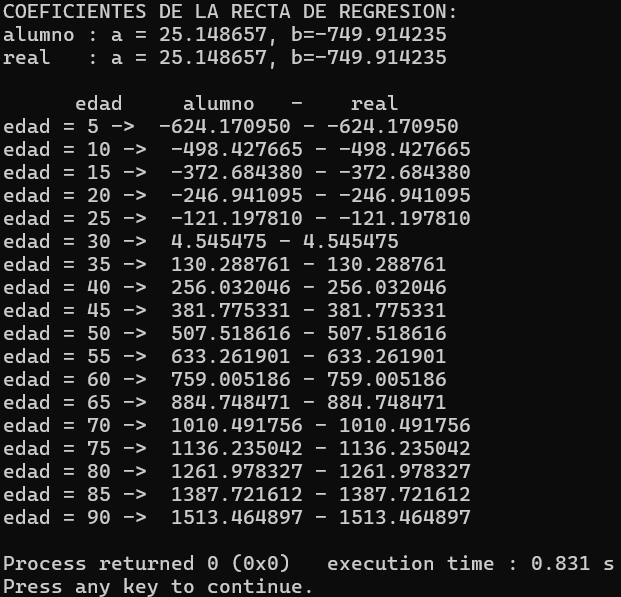

**3.7 Diferencias Newton**

In [ ]:
Array1D< real > mn_construir_polinomio_interpolador(
const Array1D< real > &X, /// VECTOR CON LOS VALORES DE LOS PUNTOS DE INTERPOLACION
const Array1D< real > &F) /// VECTOR DE VALORES DE LA FUNCION EN LOS PUNTOS DE INTERPOLACION
{
  if(X.dim()!=F.dim()) return(Array1D< real >());
  Array1D< real > A(X.dim());
  int N=X.dim()-1;
  Array1D< real > B(A.dim());

  for(int k=0;k<=N;k++){
    B[k]=F[k];
  }
  A[0]=F[0];
  for(int k=1;k<=N;k++){
    for(int l=0;l<=(N-k);l++){
      if(X[k+l]==X[l]){
        return(Array1D< real >());
      }
      B[l]=(B[l+1]-B[l])/(X[k+l]-X[l]);
    }
    A[k]=B[0];
  }
  return(A);
}

real mn_evaluar_polinomio_interpolador(
const Array1D< real > &A, /// VECTOR CON LOS COEFICIENTES DEL POLINOMIO
const Array1D< real > &X, /// VECTOR CON LOS VALORES DE LOS PUNTOS DE INTERPOLACION
const real x0) /// VALOR DONDE SE INTERPOLA EL POLINOMIO
{
  int N=A.dim()-1;
	real E=A[N];
	for(int k=N-1;k>=0;k--){
    E=E*(x0-X[k])+A[k];
  }
  return E;
}

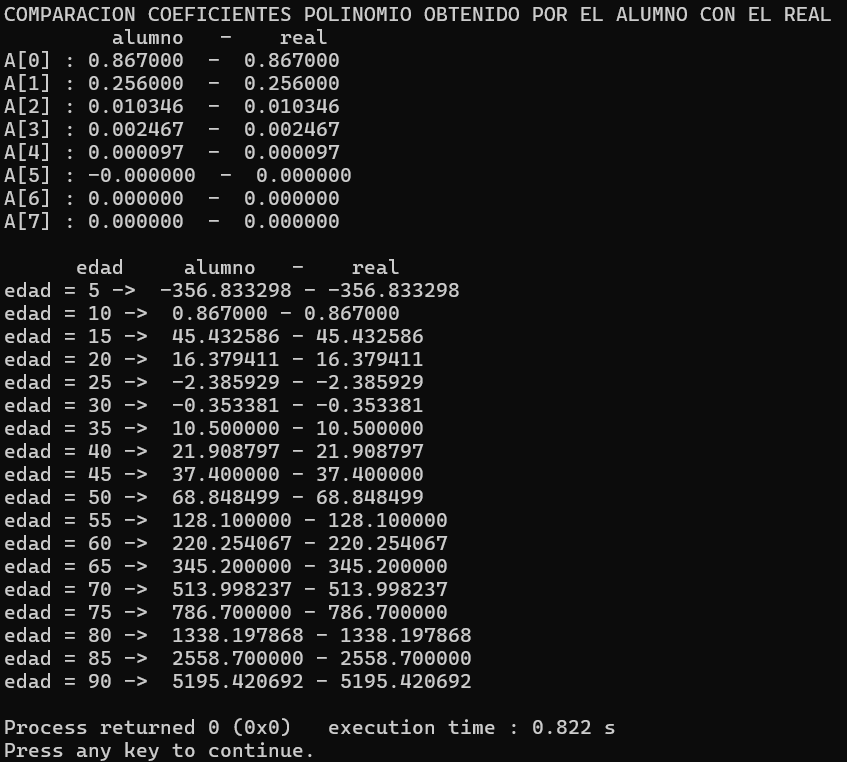

**3.8 Image Zoom Vecino**

In [ ]:
Array2D< real > zoom_vecino(
Array2D< real > &A /** IMAGEN ORIGINAL */,
real z /** FACTOR DE ZOOM */)
{
  int dim1New=A.dim1()*z;
  int dim2New=A.dim2()*z;

  if(dim1New<=0 || dim2New<=0) return Array2D< real >();

  Array2D< real > B(dim1New,dim2New);

  for(int ip=0;ip<B.dim1();ip++){
    for(int jp=0;jp<B.dim2();jp++){
      real x=ip/z;
      real y=jp/z;
      int i=x;
      int j=y;
      if((x-i)>0.5 && i+1<A.dim1()) i=i+1;
      if((y-j)>0.5 && j+1<A.dim2()) j=j+1;
      B[ip][jp]=A[i][j];
    }
  }
  return B;
}


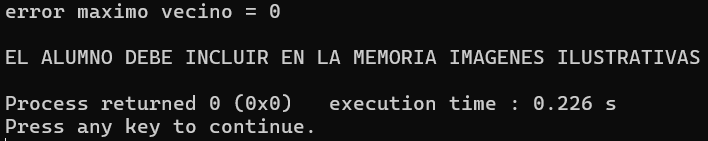

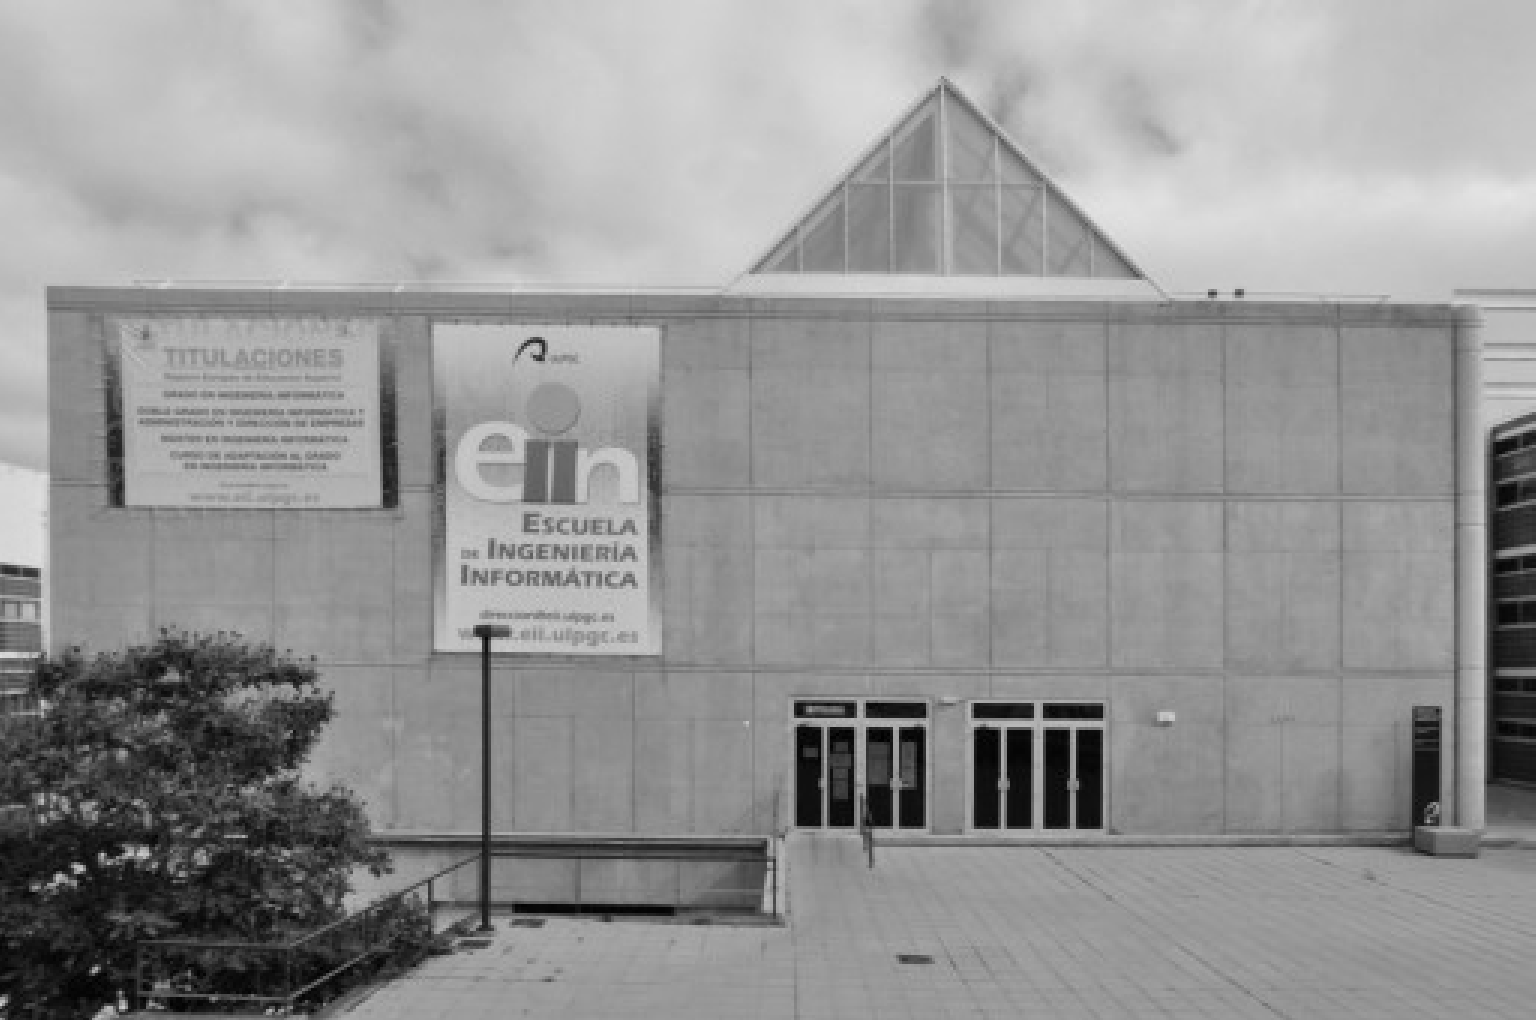

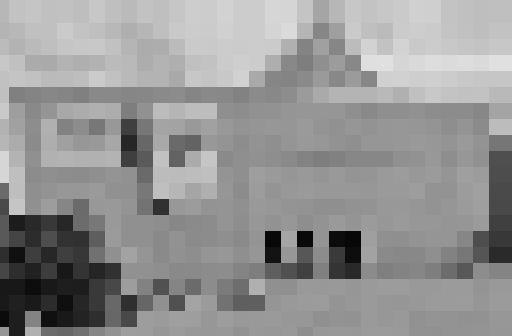

**3.9 Image Zoom Bilineal**

In [ ]:
Array2D< real > zoom_bilineal(
Array2D< real > &A /** IMAGEN ORIGINAL */,
real z /** FACTOR DE ZOOM */)
{
  int dim1New=A.dim1()*z;
  int dim2New=A.dim2()*z;

  if(dim1New<=0 || dim2New<=0) return Array2D< real >();

  Array2D< real > B(dim1New,dim2New);

  for(int ip=0;ip<B.dim1();ip++){
    for(int jp=0;jp<B.dim2();jp++){
      real x=ip/z;
      real y=jp/z;
      int i=x;
      int j=y;
      int i1=min(i+1,A.dim1()-1);
      int j1=min(j+1,A.dim2()-1);
      real dx=x-i;
      real dy=y-j;
      B[ip][jp] = (1.-dy) * ( (1.-dx)*A[i][j] + dx*A[i1][j] ) +
                      dy  * ( (1.-dx)*A[i][j1] + dx*A[i1][j1] );
    }
  }
  return B;
}

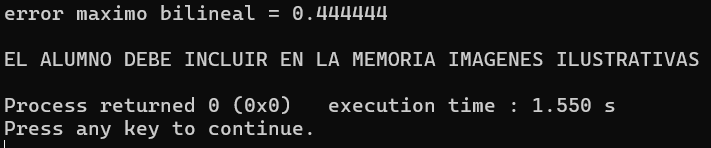

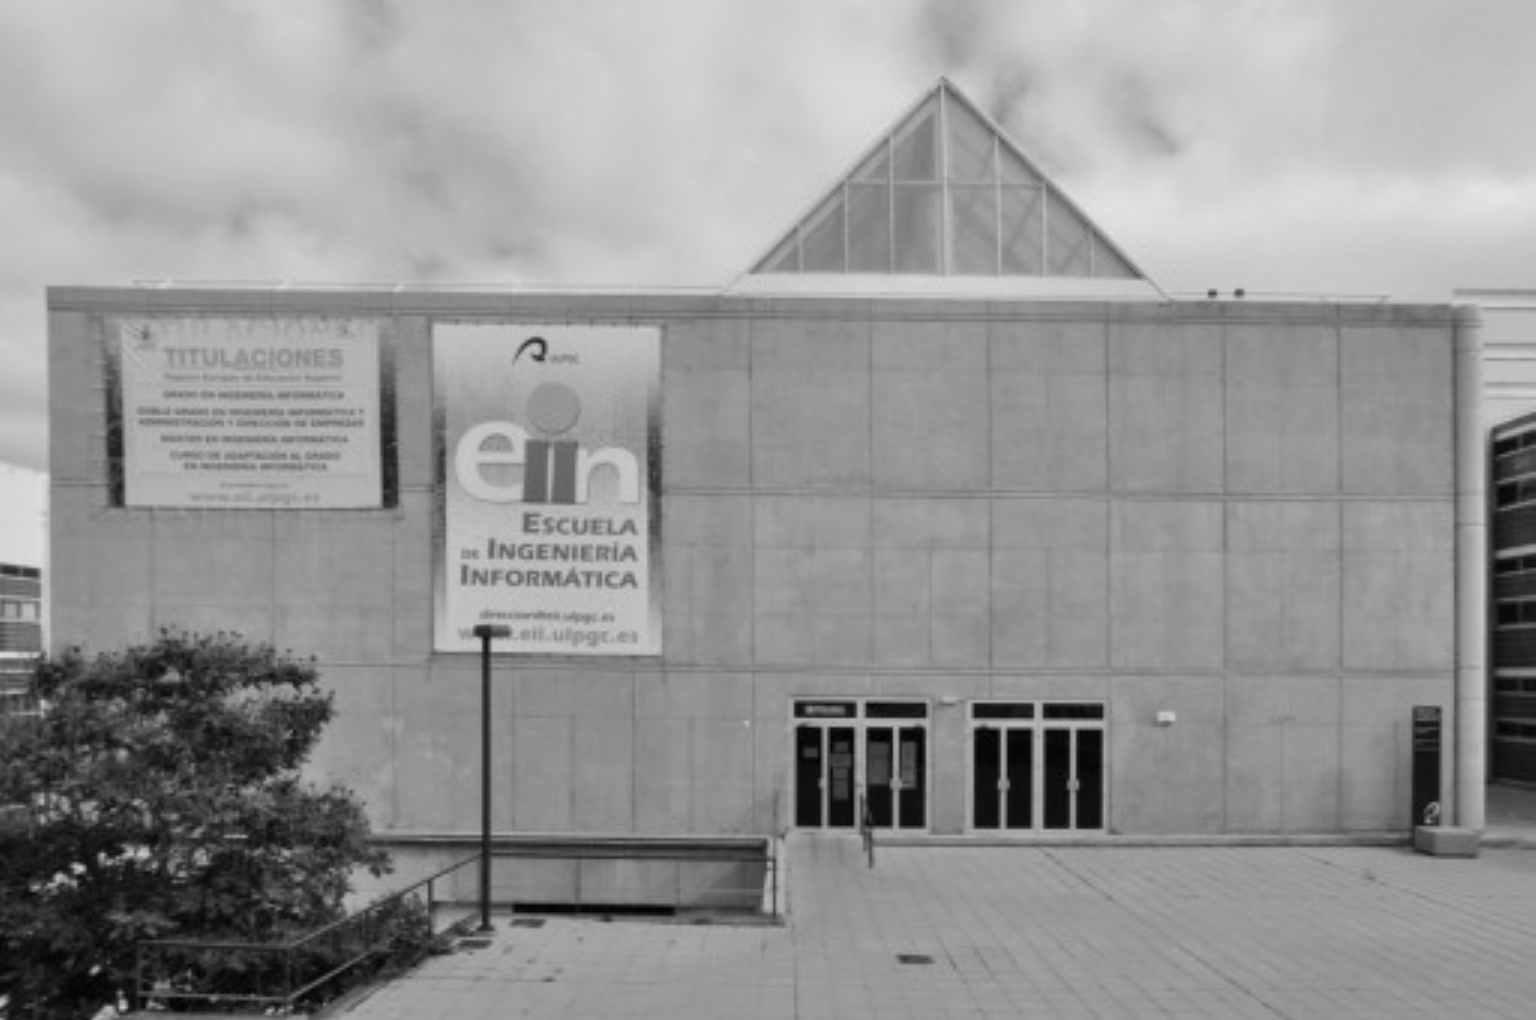

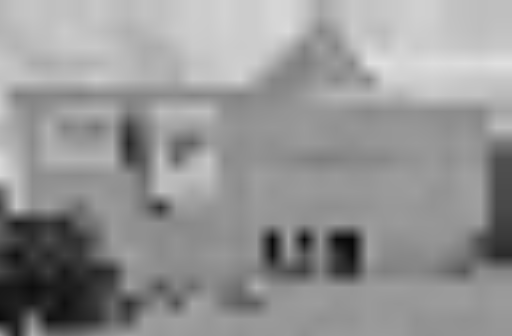

Validación: El resultado que se obtiene parece ser correcto. El error que se obtiene viene a raíz del método 
que se ha aplicado: se ha aproximado cada punto de la cuadrícula resultante a 4 puntos de la 
cuadrícula original y, al trabajar con números enteros es lo que produce ese error.
La imagen original (la primera) y la imagen aplicado el zoom 1/16 y posteriormente uno de 16 (la segunda).
Como se ve, se obtiene una imagen difuminada, producto de aproximar cada punto a 4 de los 
originales y de haber hecho más pequeña y después más grande.